# AquaSentinel — 02. Baselines and modelling

Notebook 01 established that the univariate signal in this dataset is very weak. This
notebook sets up an honest comparison:

1. **Train/test discipline** — one stratified 80/20 split, fixed seed, test set untouched
2. **Two baselines** — a majority-class dummy and a *guideline-based rule* built from
   drinking-water standards
3. **Leakage-safe preprocessing** — imputation and scaling inside scikit-learn pipelines
4. **Imputation comparison** — median vs. KNN, with and without missing indicators,
   compared under cross-validation
5. **The model zoo** — logistic regression, random forest, gradient boosting, XGBoost,
   LightGBM, each tuned with randomised search over cross-validation

> The expensive hyperparameter search lives in `scripts/run_all.py`. This notebook runs
> the cheap parts live and **reads the search results back from `results/metrics/`**, so
> the numbers here are literally the same numbers the script produced — no re-derivation,
> no drift. Run `python scripts/run_all.py` first if `results/` is empty.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

from aquasentinel import config, data, evaluate, explain, features, models

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
evaluate.apply_style()


def load_metric(stem):
    """Read a results file written by scripts/run_all.py."""
    path = config.METRICS_DIR / f"{stem}.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return pd.read_csv(config.METRICS_DIR / f"{stem}.csv")


print("Random seed:", config.RANDOM_SEED)

Random seed: 42


## 1. The split

Created once, from the fixed seed, and stratified on the unsafe label. Everything that follows — tuning, imputer selection, threshold selection — uses **only** `x_train` / `y_train`.

In [2]:
raw = data.load_raw()
split = data.make_split(raw)

print(f"Train: {split.n_train:,} rows  ({split.y_train.mean():.1%} unsafe)")
print(f"Test:  {split.n_test:,} rows  ({split.y_test.mean():.1%} unsafe)")
print(f"Overlap between train and test indices: {len(set(split.x_train.index) & set(split.x_test.index))}")

Train: 2,620 rows  (61.0% unsafe)
Test:  656 rows  (61.0% unsafe)
Overlap between train and test indices: 0


## 2. Baseline 1 — majority-class dummy

Because UNSAFE is the majority class, the dummy classifier predicts UNSAFE for every
sample. This is the bar that matters most in this project: it achieves **perfect recall**
on the costly class for free.

In [3]:
dummy = models.build_dummy_classifier().fit(split.x_train, split.y_train)
dummy_scores = dummy.predict_proba(split.x_train)[:, 1]
dummy_metrics = evaluate.classification_metrics(split.y_train, dummy_scores, 0.5)

print(f"Predicts UNSAFE for every sample: {bool((dummy.predict(split.x_train) == 1).all())}")
for key in ("roc_auc", "recall_unsafe", "precision_unsafe", "f1_unsafe", "balanced_accuracy"):
    print(f"  {key:22s} {dummy_metrics[key]:.3f}")

Predicts UNSAFE for every sample: True
  roc_auc                0.500
  recall_unsafe          1.000
  precision_unsafe       0.610
  f1_unsafe              0.758
  balanced_accuracy      0.500


## 3. Baseline 2 — the guideline-based rule

A sample is flagged UNSAFE if **any** parameter falls outside its permissible limit.

Every limit used here was looked up in an official standard and carries its source and
URL in `config.py`. Two of the nine parameters are **deliberately excluded** because no
numeric drinking-water limit could be verified for them — we would rather have a smaller
honest rule than a complete guessed one.

In [4]:
rows = []
for name, limit in config.PARAMETER_LIMITS.items():
    rows.append({
        "parameter": name,
        "lower": limit.lower,
        "upper": limit.upper,
        "unit": limit.unit,
        "source": limit.source,
    })
pd.DataFrame(rows)

,parameter,lower,upper,unit,source
0,ph,6.5,8.5,pH units,BIS IS 10500:2012 (acceptable limit; no relaxa...
1,Hardness,NaN,600.0,mg/L (as CaCO3),BIS IS 10500:2012 (permissible limit in absenc...
2,Solids,NaN,2000.0,mg/L (total dissolved solids),BIS IS 10500:2012 (permissible limit in absenc...
3,Chloramines,NaN,4.0,mg/L (as Cl2),US EPA National Primary Drinking Water Regulat...
4,Sulfate,NaN,400.0,mg/L (as SO4),BIS IS 10500:2012 (permissible limit in absenc...
5,Trihalomethanes,NaN,80.0,ug/L (total THMs),US EPA National Primary Drinking Water Regulat...
6,Turbidity,NaN,5.0,NTU,BIS IS 10500:2012 (permissible limit in absenc...


In [5]:
print("Excluded from the rule - no numeric limit could be verified:\n")
for name, reason in config.UNVERIFIED_PARAMETERS.items():
    print(f"* {name}:\n    {reason}\n")

Excluded from the rule - no numeric limit could be verified:

* Conductivity:
    Neither WHO GDWQ 4th ed. Annex 3 nor BIS IS 10500:2012 publishes a numeric drinking-water limit for electrical conductivity; conductivity is normally regulated indirectly via total dissolved solids. Excluded from the rule.

* Organic_carbon:
    WHO GDWQ 4th ed. Annex 3 lists no guideline value for total organic carbon, and the US EPA regulates TOC through required percentage removal under the Disinfectants/Disinfection By-products Rule rather than a concentration MCL. No single threshold could be verified, so it is excluded from the rule.



### How often does each limit fire?

In [6]:
violations = features.rule_violation_matrix(raw[config.FEATURES])
summary = pd.DataFrame({
    "n_breaching": violations.sum(),
    "pct_breaching": (violations.mean() * 100).round(2),
    "n_measured": raw[list(violations.columns)].notna().sum(),
}).sort_values("pct_breaching", ascending=False)
summary

,n_breaching,pct_breaching,n_measured
Solids,3271,99.85,3276
Chloramines,3187,97.28,3276
ph,1457,44.47,2785
Trihalomethanes,602,18.38,3114
Turbidity,314,9.58,3276
Sulfate,138,4.21,2495
Hardness,0,0.00,3276


**The `Solids` term dominates completely.** As flagged in notebook 01, essentially every
row exceeds the BIS permissible TDS limit, so "any parameter out of range" is true for
almost the whole dataset. That makes the rule nearly a constant predictor — which is a
genuine finding about applying real drinking-water standards to this dataset, not a bug.
We keep it and report it.

In [7]:
rule_pred = features.rule_baseline_predict(raw[config.FEATURES])
target = data.to_unsafe_label(raw)
rule_metrics = evaluate.classification_metrics(target, rule_pred.astype(float), 0.5)

print(f"Share of samples the rule flags as UNSAFE: {rule_pred.mean():.1%}\n")
for key in ("recall_unsafe", "precision_unsafe", "f1_unsafe", "balanced_accuracy"):
    print(f"  {key:22s} {rule_metrics[key]:.3f}")
print("\nWithout the Solids term, for comparison:")
without_solids = violations.drop(columns=["Solids"]).any(axis=1).astype(int)
reduced = evaluate.classification_metrics(target, without_solids.to_numpy().astype(float), 0.5)
print(f"  flag rate              {without_solids.mean():.3f}")
for key in ("recall_unsafe", "precision_unsafe", "balanced_accuracy"):
    print(f"  {key:22s} {reduced[key]:.3f}")

Share of samples the rule flags as UNSAFE: 100.0%

  recall_unsafe          1.000
  precision_unsafe       0.610
  f1_unsafe              0.758
  balanced_accuracy      0.500

Without the Solids term, for comparison:
  flag rate              0.990
  recall_unsafe          0.989
  precision_unsafe       0.610
  balanced_accuracy      0.500


## 4. Leakage-safe preprocessing

Every model is a `Pipeline` whose **first** step is a `ColumnTransformer` holding the
imputer and scaler. Because the transformer lives inside the estimator, scikit-learn
refits it on the training part of every cross-validation fold. Nothing is ever fitted on
data the model is about to be scored on.

The cell below demonstrates the property that `tests/test_pipeline_no_leakage.py`
asserts: the imputer's learned medians come from the training set, not the full dataset.

In [8]:
preprocessor = features.build_preprocessor(imputer="median", scale=True)
preprocessor.fit(split.x_train)
learned = preprocessor.named_transformers_["numeric"].named_steps["impute"].statistics_

comparison = pd.DataFrame({
    "imputer_learned": learned,
    "train_median": split.x_train[config.FEATURES].median().to_numpy(),
    "full_dataset_median": raw[config.FEATURES].median().to_numpy(),
}, index=config.FEATURES).round(4)
comparison["matches_train"] = np.isclose(comparison["imputer_learned"], comparison["train_median"])
comparison

,imputer_learned,train_median,full_dataset_median,matches_train
ph,7.0490,7.0490,7.0368,True
Hardness,197.5826,197.5826,196.9676,True
Solids,21051.3111,21051.3111,20927.8336,True
Chloramines,7.1238,7.1238,7.1303,True
Sulfate,333.4915,333.4915,333.0735,True
Conductivity,421.4408,421.4408,421.8850,True
Organic_carbon,14.2494,14.2494,14.2183,True
Trihalomethanes,66.3009,66.3009,66.6225,True
Turbidity,3.9430,3.9430,3.9550,True


In [9]:
print("Imputer statistics equal the TRAIN medians:", bool(comparison['matches_train'].all()))
print("Imputer statistics equal the FULL-dataset medians:",
      bool(np.allclose(comparison['imputer_learned'], comparison['full_dataset_median'])))
print("\n-> The second line must be False. If it were True, every reported metric would be")
print("   optimistically biased by test-set information leaking into imputation.")

Imputer statistics equal the TRAIN medians: True
Imputer statistics equal the FULL-dataset medians: False

-> The second line must be False. If it were True, every reported metric would be
   optimistically biased by test-set information leaking into imputation.


### Each candidate model carries its own preprocessing

In [10]:
for spec in models.build_model_specs():
    first_step = spec.pipeline.steps[0][0]
    searches_imputer = "preprocess__numeric__impute" in spec.param_distributions
    print(f"{spec.name:22s} first step={first_step:12s} imputer tuned in CV={searches_imputer}")

Logistic Regression    first step=preprocess   imputer tuned in CV=True
Random Forest          first step=preprocess   imputer tuned in CV=True
Gradient Boosting      first step=preprocess   imputer tuned in CV=True


## 5. Imputation strategies compared under cross-validation

Median vs. KNN, each with and without missing-indicator columns. All four are scored with
the same held-out folds on the training set only. These are the numbers
`scripts/run_all.py` wrote to `results/metrics/imputer_comparison.csv`.

In [11]:
imputers = load_metric("imputer_comparison")
imputers.round(4)

,imputer,cv_roc_auc_mean,cv_roc_auc_std
0,knn,0.6834,0.0116
1,knn_indicator,0.6806,0.0124
2,median,0.6801,0.0083
3,median_indicator,0.6762,0.0068


The four strategies land within roughly half a standard deviation of each other — the
choice of imputer is **not** what limits performance here. Rather than pick a winner by
hand, the imputation strategy is included in each model's randomised search space, so it
is selected per model, inside cross-validation.

## 6. The model zoo and the tuned results

Five model families, each tuned with a 40-candidate randomised search over 5-fold
stratified CV on the training set, then re-scored under repeated (5-fold × 3) CV for the
reported mean and standard deviation. Class imbalance is handled deliberately via
`class_weight` / `scale_pos_weight` options inside the search space, so the choice is made
by cross-validation rather than asserted.

In [12]:
for spec in models.build_model_specs():
    n_options = {k: len(v) for k, v in spec.param_distributions.items()}
    total = int(np.prod(list(n_options.values())))
    print(f"{spec.name:22s} {len(spec.param_distributions)} hyperparameters, "
          f"{total:,} possible combinations")

Logistic Regression    4 hyperparameters, 96 possible combinations
Random Forest          6 hyperparameters, 2,160 possible combinations
Gradient Boosting      6 hyperparameters, 1,296 possible combinations


In [13]:
leaderboard = load_metric("model_leaderboard")
leaderboard.round(4)

,model,kind,cv_roc_auc_mean,cv_roc_auc_std,search_best_roc_auc,chosen_imputer,chosen_imputer_add_indicator,fit_seconds
0,Random Forest,model,0.6877,0.0183,0.6934,SimpleImputer,True,268.2
1,Gradient Boosting,model,0.6683,0.0208,0.6774,KNNImputer,True,180.5
2,XGBoost,model,0.6652,0.0161,0.6716,SimpleImputer,True,117.4
3,LightGBM,model,0.6592,0.0198,0.6730,SimpleImputer,True,114.6
4,Guideline rule baseline,baseline,0.5283,0.0185,NaN,NaN,NaN,NaN
5,Logistic Regression,model,0.5095,0.0224,0.5141,SimpleImputer,False,7.8
6,Dummy (majority class),baseline,0.5000,0.0000,NaN,NaN,NaN,NaN


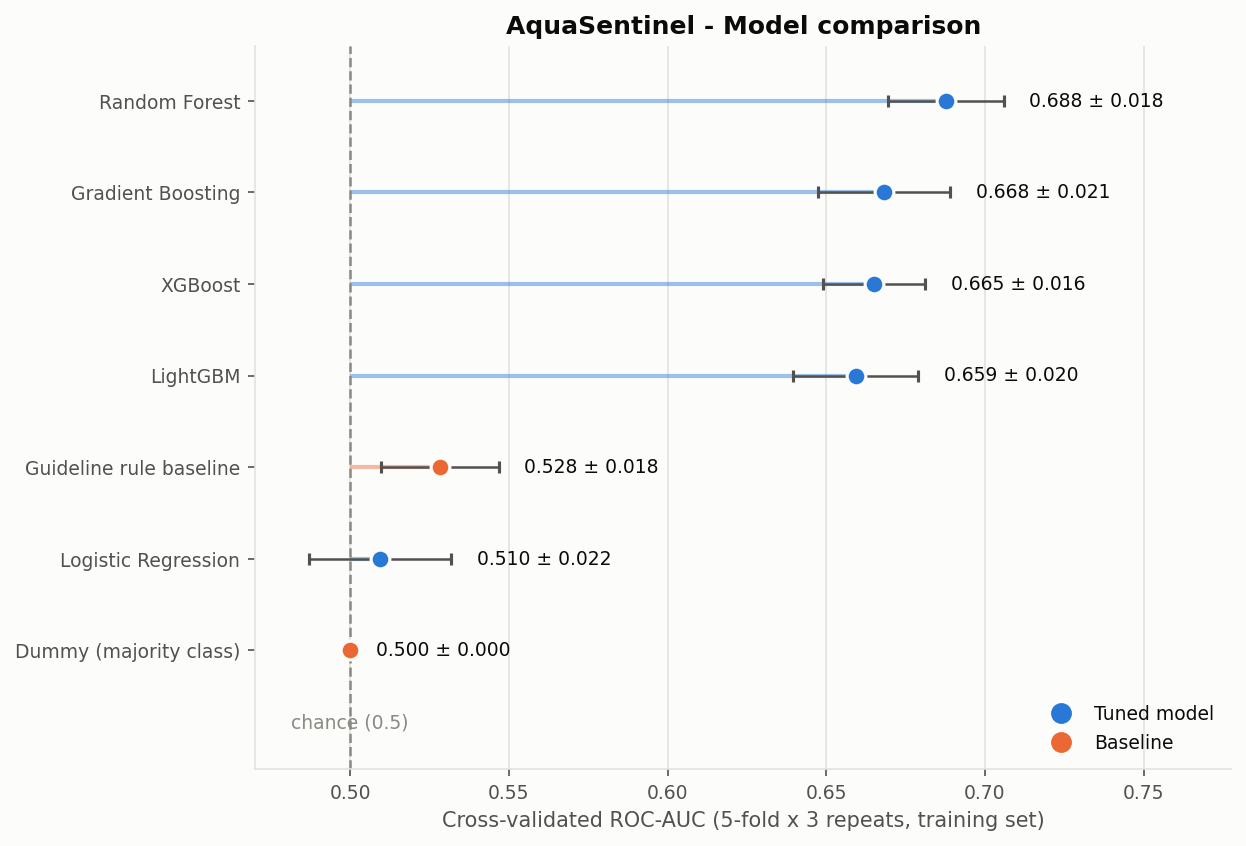

In [14]:
evaluate.plot_model_comparison(leaderboard, "05_model_comparison")
Image(str(config.FIGURES_DIR / "05_model_comparison.png"))

In [15]:
full = load_metric("model_leaderboard_full")
for entry in full:
    if entry["kind"] != "model":
        continue
    print(f"\n{entry['model']}  (CV ROC-AUC {entry['cv_roc_auc_mean']:.4f} +/- {entry['cv_roc_auc_std']:.4f})")
    print(f"  imputer chosen: {entry.get('chosen_imputer')}"
          f"{' + indicators' if entry.get('chosen_imputer_add_indicator') else ''}")
    for key, value in sorted(entry["best_params"].items()):
        if not key.endswith("impute"):
            print(f"  {key:42s} {value}")


Logistic Regression  (CV ROC-AUC 0.5095 +/- 0.0224)
  imputer chosen: SimpleImputer
  model__C                                   0.1
  model__class_weight                        None
  model__penalty                             l1

Random Forest  (CV ROC-AUC 0.6877 +/- 0.0183)
  imputer chosen: SimpleImputer + indicators
  model__class_weight                        balanced
  model__max_depth                           12
  model__max_features                        0.5
  model__min_samples_leaf                    1
  model__n_estimators                        800

Gradient Boosting  (CV ROC-AUC 0.6683 +/- 0.0208)
  imputer chosen: KNNImputer + indicators
  model__learning_rate                       0.02
  model__max_depth                           5
  model__min_samples_leaf                    5
  model__n_estimators                        200
  model__subsample                           0.7

XGBoost  (CV ROC-AUC 0.6652 +/- 0.0161)
  imputer chosen: SimpleImputer + indicators
  model_

## Observations

1. **Tree ensembles clear both baselines; logistic regression does not.** The linear model
   sits essentially at chance, which is consistent with notebook 01: no feature has a
   usable linear relationship with the target. Whatever signal exists is interaction-driven.

2. **Random Forest is the strongest family**, and its fold-to-fold standard deviation is
   the smallest of the five — it is both the best and the most stable.

3. **The guideline rule baseline barely beats chance.** Real drinking-water limits do not
   explain this dataset's labels. Given the `Solids` unit problem, that is about as
   expected as it is damning for the dataset's realism.

4. **Imputation choice is not the bottleneck.** All four strategies perform within noise
   of each other.

The next notebook takes the winner, chooses an operating threshold deliberately, and
spends the test set exactly once.

Next: **03_evaluation_and_explainability.ipynb**.